<a href="https://colab.research.google.com/github/U-ROHITH/Machine-Learning/blob/main/Model_based_vs_Instance_Based.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET LOADED
     location  sqft  rooms  price_lakhs
     Madhapur  1824      4         98.7
 Secunderabad  1528      1         63.3
 Dilsukhnagar  2636      2         92.0
   Kukatpally  1524      2         70.5
Banjara Hills  2181      4        116.3
Banjara Hills   989      3         73.5
Banjara Hills  2217      2        115.9
 Secunderabad   855      3         59.9
   Kukatpally  1308      4         71.0
 Dilsukhnagar  2438      4         89.9

Total houses : 500

Training : 400 houses
Testing  : 100 houses

MODEL 1 — LINEAR REGRESSION (Model Based)
>> Learns a pattern once. Uses it forever.

Training Time  : 40.73 ms
Prediction Time: 3.48 ms
R² Score       : 0.75
MAE            : ₹9.0 Lakhs

MODEL 2 — KNN (Instance Based)
>> Memorizes everything. Scans all data on every prediction.

Training Time  : 15.22 ms
Prediction Time: 9.88 ms
R² Score       : 0.63
MAE            : ₹10.7 Lakhs

HEAD TO HEAD COMPARISON
Metric                 Linear Reg          KNN
------------------------

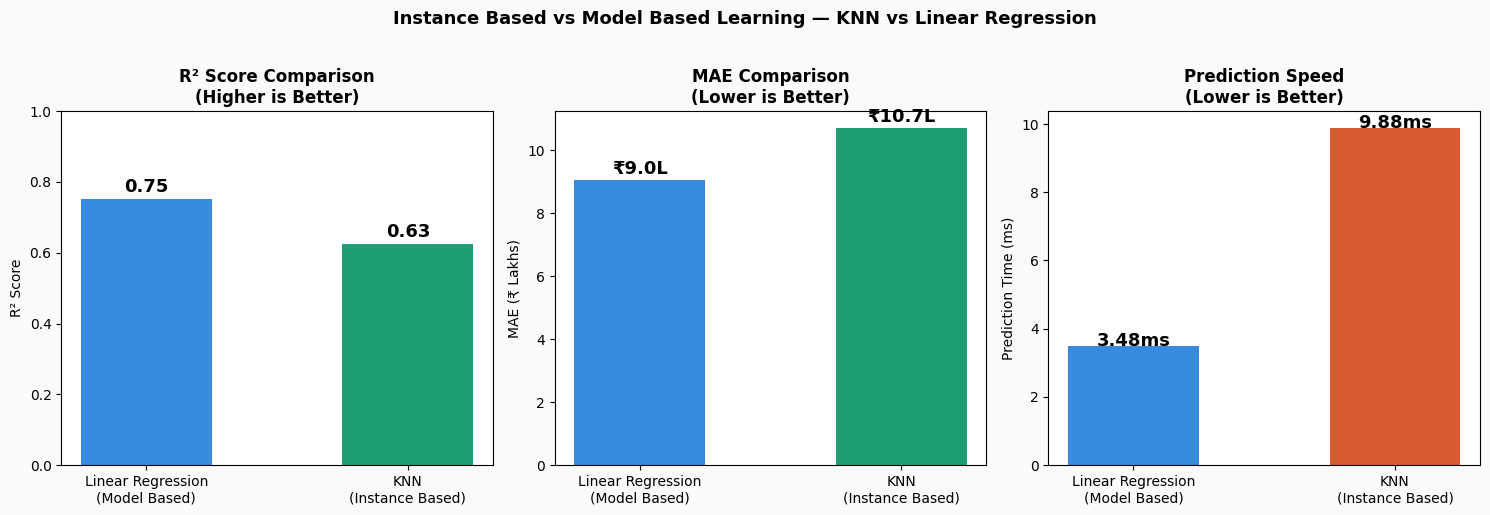

>> Accuracy vs Speed. That is the core tradeoff.


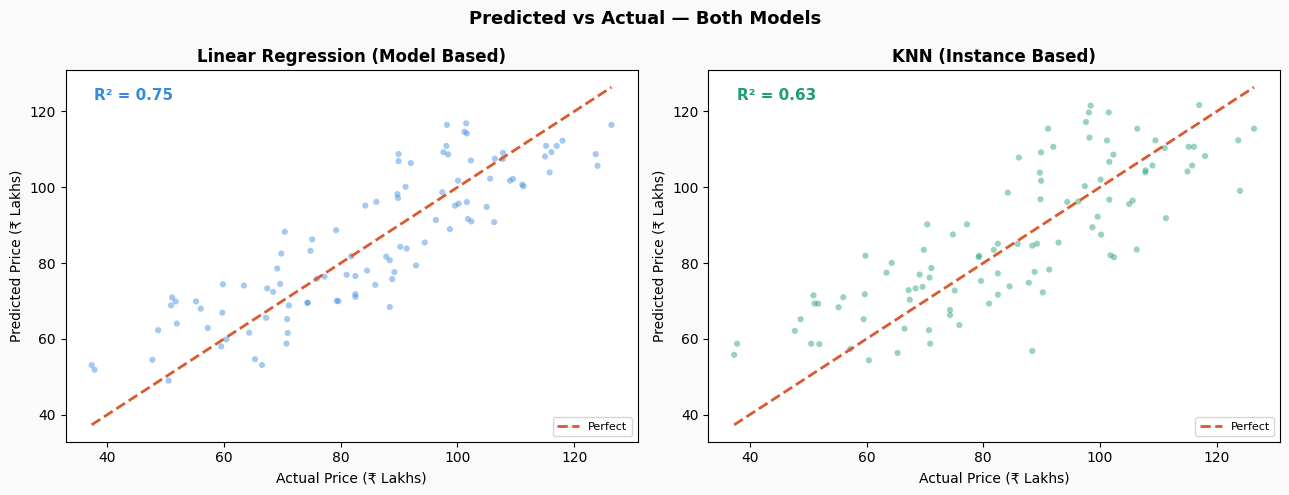

>> Tighter cluster around the diagonal = better predictions

LIVE PREDICTION — SAME HOUSE, BOTH MODELS
Input  : 1200 sqft | 3 rooms | Madhapur
Linear Regression : ₹69.7 Lakhs
KNN               : ₹63.4 Lakhs

>> Same house. Different answers. Different reasoning.
>> LR used a formula. KNN looked at 5 similar houses and averaged.

Day 2 done. 98 to go.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import time
import warnings
warnings.filterwarnings('ignore')

# ── LOAD DATA ────────────────────────────────────────────────────────────────
df = pd.read_csv('house_prices.csv')
print("=" * 50)
print("DATASET LOADED")
print("=" * 50)
print(df.head(10).to_string(index=False))
print(f"\nTotal houses : {len(df)}")

# ── PREPROCESS ───────────────────────────────────────────────────────────────
le = LabelEncoder()
df['location_enc'] = le.fit_transform(df['location'])
X = df[['sqft', 'rooms', 'location_enc']]
y = df['price_lakhs']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining : {len(X_train)} houses")
print(f"Testing  : {len(X_test)} houses")

# ── TRAIN LINEAR REGRESSION ──────────────────────────────────────────────────
print("\n" + "=" * 50)
print("MODEL 1 — LINEAR REGRESSION (Model Based)")
print("=" * 50)
print(">> Learns a pattern once. Uses it forever.")

lr_train_start = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_train_time = (time.time() - lr_train_start) * 1000

lr_pred_start = time.time()
lr_pred = lr.predict(X_test)
lr_pred_time = (time.time() - lr_pred_start) * 1000

lr_r2  = r2_score(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)
print(f"\nTraining Time  : {lr_train_time:.2f} ms")
print(f"Prediction Time: {lr_pred_time:.2f} ms")
print(f"R² Score       : {lr_r2:.2f}")
print(f"MAE            : ₹{lr_mae:.1f} Lakhs")

# ── TRAIN KNN ────────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("MODEL 2 — KNN (Instance Based)")
print("=" * 50)
print(">> Memorizes everything. Scans all data on every prediction.")

knn_train_start = time.time()
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
knn_train_time = (time.time() - knn_train_start) * 1000

knn_pred_start = time.time()
knn_pred = knn.predict(X_test)
knn_pred_time = (time.time() - knn_pred_start) * 1000

knn_r2  = r2_score(y_test, knn_pred)
knn_mae = mean_absolute_error(y_test, knn_pred)
print(f"\nTraining Time  : {knn_train_time:.2f} ms")
print(f"Prediction Time: {knn_pred_time:.2f} ms")
print(f"R² Score       : {knn_r2:.2f}")
print(f"MAE            : ₹{knn_mae:.1f} Lakhs")

# ── COMPARISON PRINT ─────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("HEAD TO HEAD COMPARISON")
print("=" * 50)
print(f"{'Metric':<20} {'Linear Reg':>12} {'KNN':>12}")
print("-" * 50)
print(f"{'R² Score':<20} {lr_r2:>12.2f} {knn_r2:>12.2f}")
print(f"{'MAE (₹ Lakhs)':<20} {lr_mae:>12.1f} {knn_mae:>12.1f}")
print(f"{'Train Time (ms)':<20} {lr_train_time:>12.2f} {knn_train_time:>12.2f}")
print(f"{'Predict Time (ms)':<20} {lr_pred_time:>12.2f} {knn_pred_time:>12.2f}")
winner = "KNN" if knn_r2 > lr_r2 else "Linear Regression"
print(f"\n>> Accuracy winner  : {winner}")
print(f">> Speed winner     : Linear Regression")
print(f">> KNN is {knn_pred_time/lr_pred_time:.0f}x slower on prediction")

# ── CHART 1: R² Comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#FAFAFA')

BLUE  = '#378ADD'
GREEN = '#1D9E75'
AMBER = '#EF9F27'
CORAL = '#D85A30'
GRAY  = '#888780'

axes[0].bar(['Linear Regression\n(Model Based)', 'KNN\n(Instance Based)'],
            [lr_r2, knn_r2], color=[BLUE, GREEN], width=0.5, edgecolor='none')
axes[0].set_ylim(0, 1)
axes[0].set_title('R² Score Comparison\n(Higher is Better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score')
for i, v in enumerate([lr_r2, knn_r2]):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=13, fontweight='bold')

# ── CHART 2: MAE Comparison ──────────────────────────────────────────────────
axes[1].bar(['Linear Regression\n(Model Based)', 'KNN\n(Instance Based)'],
            [lr_mae, knn_mae], color=[BLUE, GREEN], width=0.5, edgecolor='none')
axes[1].set_title('MAE Comparison\n(Lower is Better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE (₹ Lakhs)')
for i, v in enumerate([lr_mae, knn_mae]):
    axes[1].text(i, v + 0.2, f'₹{v:.1f}L', ha='center', fontsize=13, fontweight='bold')

# ── CHART 3: Speed Comparison ────────────────────────────────────────────────
axes[2].bar(['Linear Regression\n(Model Based)', 'KNN\n(Instance Based)'],
            [lr_pred_time, knn_pred_time], color=[BLUE, CORAL], width=0.5, edgecolor='none')
axes[2].set_title('Prediction Speed\n(Lower is Better)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Prediction Time (ms)')
for i, v in enumerate([lr_pred_time, knn_pred_time]):
    axes[2].text(i, v + 0.01, f'{v:.2f}ms', ha='center', fontsize=13, fontweight='bold')

plt.suptitle('Instance Based vs Model Based Learning — KNN vs Linear Regression',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(">> Accuracy vs Speed. That is the core tradeoff.")

# ── CHART 4: Predicted vs Actual Both Models ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#FAFAFA')

for ax, pred, label, color in zip(
    axes,
    [lr_pred, knn_pred],
    ['Linear Regression (Model Based)', 'KNN (Instance Based)'],
    [BLUE, GREEN]
):
    ax.scatter(y_test, pred, color=color, alpha=0.45, s=20, edgecolors='none')
    mn, mx = min(y_test.min(), pred.min()), max(y_test.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], color=CORAL, lw=2, linestyle='--', label='Perfect')
    r2 = r2_score(y_test, pred)
    ax.text(0.05, 0.92, f'R² = {r2:.2f}', transform=ax.transAxes,
            fontsize=11, color=color, fontweight='bold')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Price (₹ Lakhs)')
    ax.set_ylabel('Predicted Price (₹ Lakhs)')
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs Actual — Both Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(">> Tighter cluster around the diagonal = better predictions")

# ── SINGLE PREDICTION DEMO ───────────────────────────────────────────────────
print("\n" + "=" * 50)
print("LIVE PREDICTION — SAME HOUSE, BOTH MODELS")
print("=" * 50)
sample = pd.DataFrame({
    'sqft'        : [1200],
    'rooms'       : [3],
    'location_enc': [le.transform(['Madhapur'])[0]]
})
lr_single  = lr.predict(sample)[0]
knn_single = knn.predict(sample)[0]
print(f"Input  : 1200 sqft | 3 rooms | Madhapur")
print(f"Linear Regression : ₹{lr_single:.1f} Lakhs")
print(f"KNN               : ₹{knn_single:.1f} Lakhs")
print(f"\n>> Same house. Different answers. Different reasoning.")
print(f">> LR used a formula. KNN looked at 5 similar houses and averaged.")
print("\nDay 2 done. 98 to go.")